## Import Libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [13]:
df = pd.read_csv("../data/raw/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Basic Information

In [15]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

## Missing Values

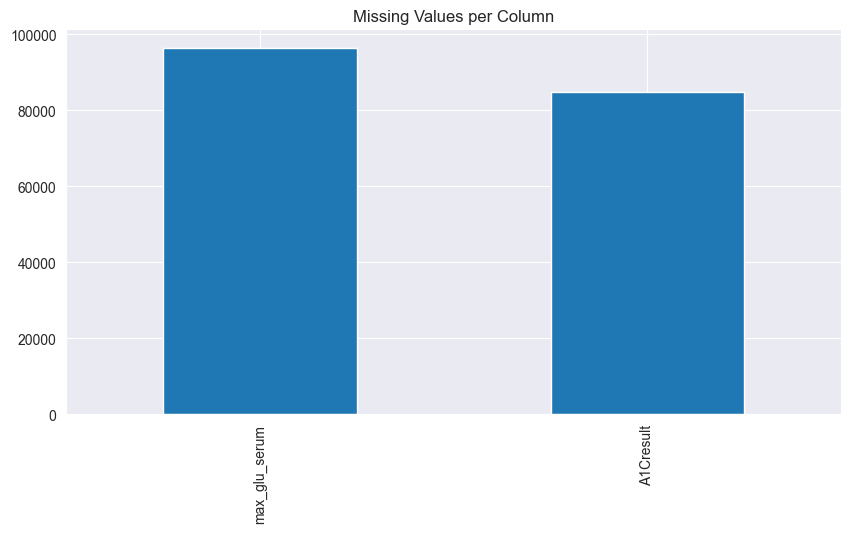

In [16]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Values per Column")
plt.show()

In [17]:
(df == '?').sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

## Target Variable Analysis

In [19]:
# Summary statistics
df.describe()

# Unique values in target
df['readmitted'].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

## Visualization:

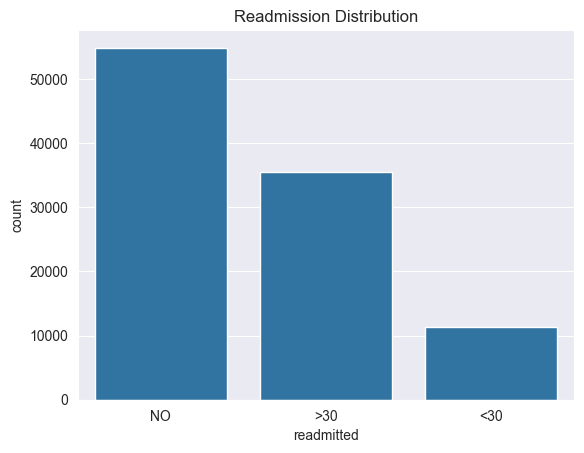

In [20]:
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.show()

## Key Feature Analysis

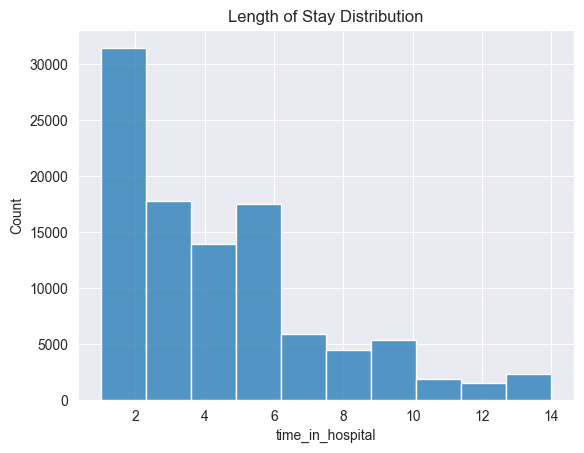

In [21]:
sns.histplot(df['time_in_hospital'], bins=10)
plt.title("Length of Stay Distribution")
plt.show()

## Age vs Readmission

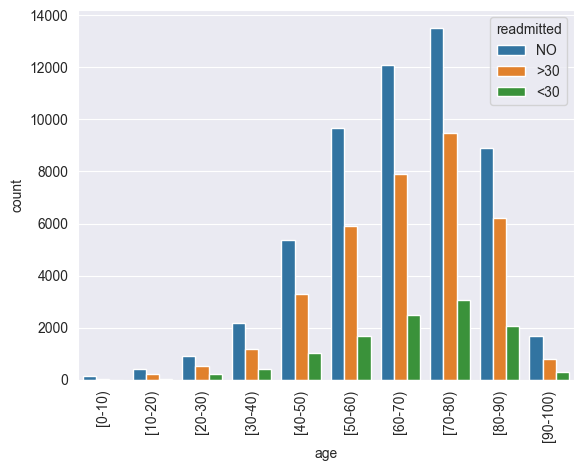

In [22]:
sns.countplot(x='age', hue='readmitted', data=df)
plt.xticks(rotation=90)
plt.show()

## Readmission vs Hospital Stay

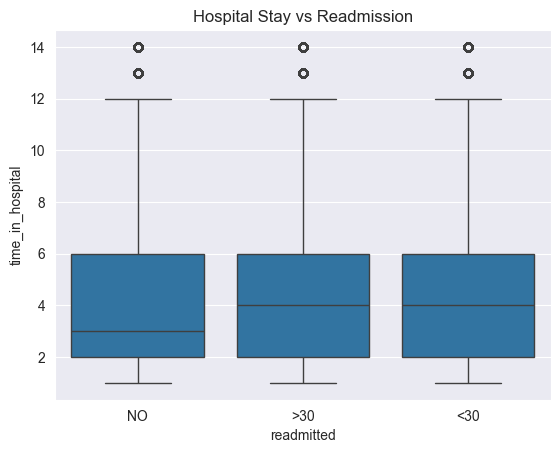

In [24]:
df_clean = df.replace('?', pd.NA)
sns.boxplot(x='readmitted', y='time_in_hospital', data=df_clean)
plt.title("Hospital Stay vs Readmission")
plt.show()

## Number of Visits Analysis

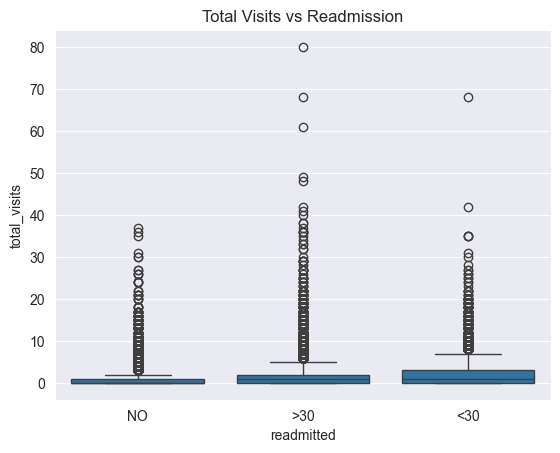

In [25]:
df_clean['total_visits'] = (
    df_clean['number_outpatient'] +
    df_clean['number_emergency'] +
    df_clean['number_inpatient']
)

sns.boxplot(x='readmitted', y='total_visits', data=df_clean)
plt.title("Total Visits vs Readmission")
plt.show()

## Correlation (Numerical)

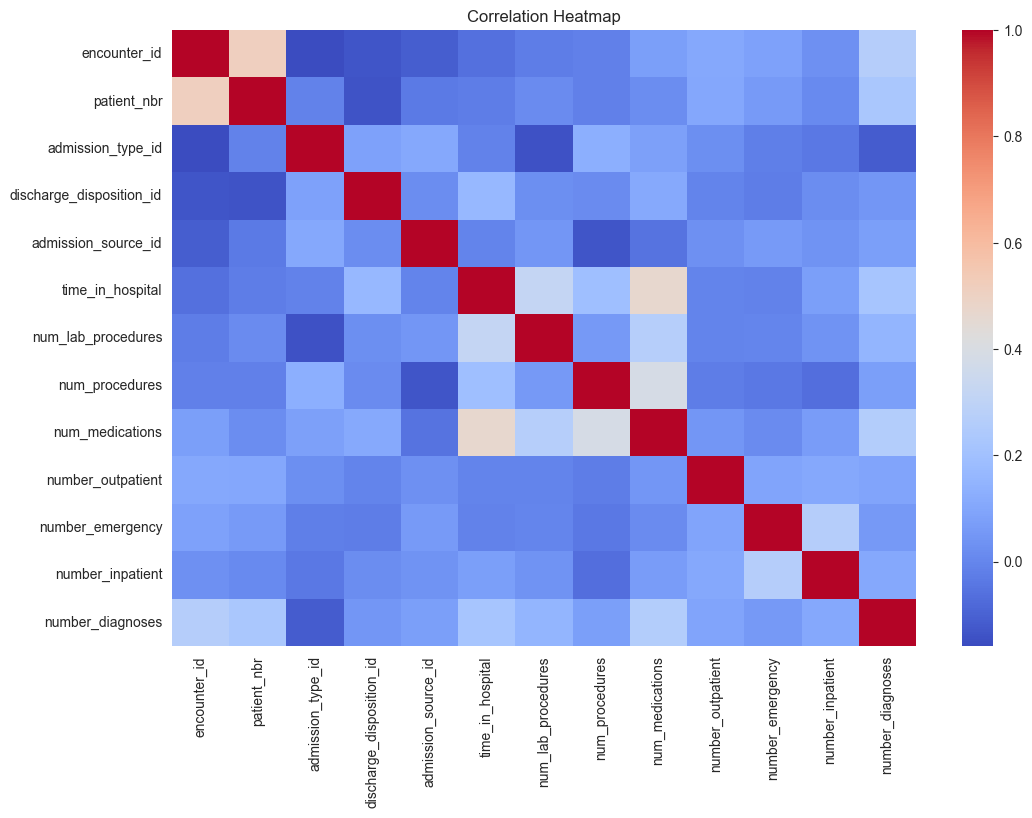

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Insights Section

- The majority of patients are not readmitted, indicating class imbalance in the dataset
- Patients with longer hospital stays tend to have a higher likelihood of readmission
- Higher numbers of previous visits (inpatient/emergency) are associated with increased readmission risk
- Several columns contain missing or invalid values (?), requiring cleaning during the ETL process
- Some features have weak correlation, indicating the need for feature engineering for better predictive performance